In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

from numpy.typing import NDArray
from typing import Union
from torch.utils.data import DataLoader
from nn_helpers import MoogStokesNN
from spectra import SpectralDataForMoogStokes, MoogStokesModel, setup_regions_plot

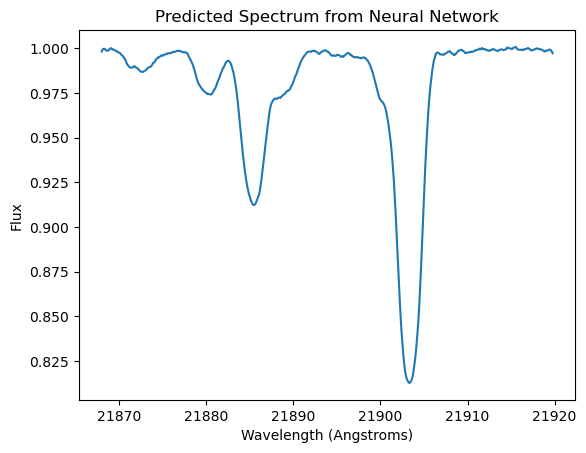

In [2]:
moognn = MoogStokesNN() # use this to generate models for MCMC, like this:
testmodel = moognn.make_moogstokes_model(Teff=3982, logg=3.9, rK=0.2, B=1.6, vsini=23, region=2)
plt.figure()
plt.plot(testmodel.x, testmodel.y)
plt.xlabel("Wavelength (Angstroms)")
plt.ylabel("Flux")
plt.title("Predicted Spectrum from Neural Network")
plt.show()

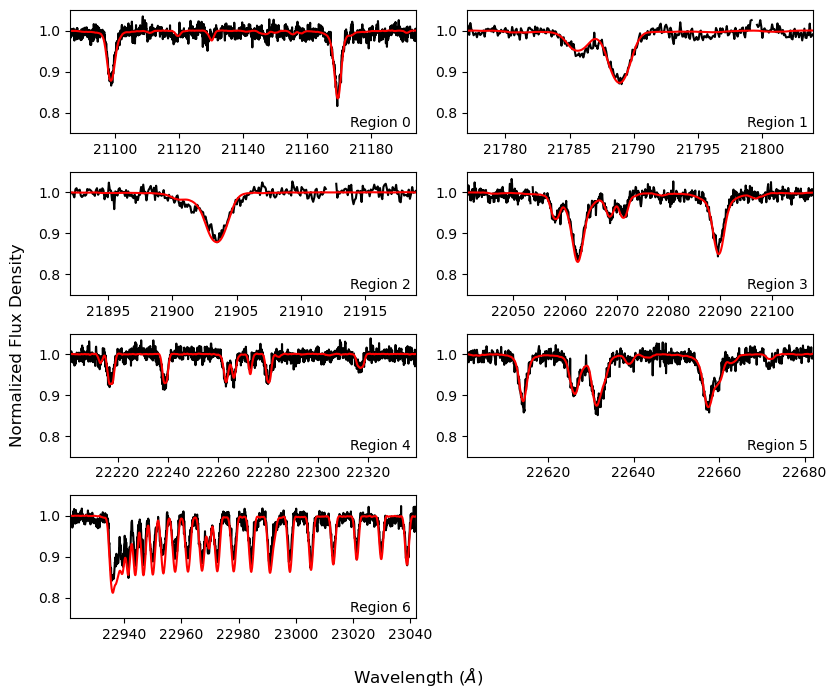

In [3]:
shifts = np.array([-33, -33, -30, -33, -33, -33, -33])
#shifts = np.array([-11, -11, -10, -11, -11, -11, -11])

renormalization = np.array([1.002, 1.0, 1.004, 1.001, 1.003, 1.004, 1.001])
regions = range(7)

testdata = SpectralDataForMoogStokes("data/science/Spectrum_CI_Tau_Class-II-sources.nspec",
                                     name="CI Tau", regions=regions, shifts=shifts, renormalization=renormalization)
#testdata.Nyquist_bin_spectrum(3)

Teff = 3888
logg = 3.74
rK = 1.87
B = 1.78
vsini = 12.71

fig, axs = setup_regions_plot()
for r in range(7):
    x, y, yerr = testdata.get_region(r)
    axs[r].plot(x, y, label="Observed", color="black")
    testmodel = moognn.make_moogstokes_model(Teff=Teff, logg=logg, rK=rK, B=B, vsini=vsini, region=r)
    axs[r].plot(testmodel.x, testmodel.y, label="Model", color="red")
    axs[r].set_ylim(0.75, 1.05)

plt.show()

In [29]:
def lnlike(self, p):
    """
    Returns the log-likelihood. ln L = -0.5 * Chi-squared by definition.
    
    Parameters
    ----------
    p: ndarray
        The parameters used to define the convolution kernel.
    """
    y_model = self.convolve_template(p)
    return -0.5 * np.nansum((self.data.y-y_model)**2/self.data.y_err**2)

def lnprob(self, p):
    """
    Returns the log-probability.

    Parameters
    ----------
    p: ndarray
        The parameters used to define the convolution kernel.
    """
    lp = ck.lnprior(p)
    if not np.isfinite(lp):
        return -np.inf
    return lp + self.lnlike(p)


In [30]:
def lnlike(p: NDArray, spectrum: SpectralDataForMoogStokes, model_generator: MoogStokesNN,
           regions: Union[range, list[int]]) -> float:
    ydata_all = []
    ymodel_all = []
    yerr_all = []

    for r in regions:
        x, y, yerr = spectrum.get_region(r)
        model = model_generator.make_moogstokes_model(Teff=p[0], logg=p[1], rK=p[2],
                                                      B=p[3], vsini=p[4], region=r)
        ymodel = model.interpolate(x)

        ydata_all.append(y)
        ymodel_all.append(ymodel)
        yerr_all.append(yerr)
        
    ydata_all = np.concatenate(ydata_all)
    ymodel_all = np.concatenate(ymodel_all)
    yerr_all = np.concatenate(yerr_all)
    return -0.5 * np.nansum((ydata_all-ymodel_all)**2/yerr_all**2)

def lnprob(p: NDArray, spectrum: SpectralDataForMoogStokes, model_generator: MoogStokesNN,
           regions: Union[range, list[int]]) -> float:
    lp = lnprior(p)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(p, spectrum, model_generator, regions)

def lnprior(p: NDArray) -> float:
    Teff, logg, rK, B, vsini = p
    if not (3200 <= Teff <= 7000):
        return -np.inf
    if not (2.5 <= logg <= 5.1):
        return -np.inf
    if not (2.0 <= vsini <= 57):
        return -np.inf
    if not (0 <= B <= 3):
        return -np.inf
    return 0

In [31]:
nwalkers = 32
pos = np.random.uniform(low=[3200, 2.5, 0.0, 0.0, 2.0], high=[7000, 5.1, 1.0, 3.0, 57], size=(nwalkers, 5))
ndim = pos.shape[1]

sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=(testdata, moognn, range(1, 4)))
sampler.run_mcmc(pos, 3000, progress=True)

100%|██████████| 3000/3000 [03:37<00:00, 13.80it/s]


State([[4.00572159e+03 3.67654104e+00 1.88255081e+00 1.74416257e+00
  1.52675947e+01]
 [3.97036801e+03 3.69147277e+00 1.95033746e+00 1.76991197e+00
  1.50022374e+01]
 [3.98433744e+03 3.68124570e+00 1.94270084e+00 1.81398591e+00
  1.45536385e+01]
 [4.00183066e+03 3.74794969e+00 1.93793208e+00 1.78793212e+00
  1.38535410e+01]
 [3.98036013e+03 3.64474758e+00 1.89189921e+00 1.64709037e+00
  1.49429121e+01]
 [3.99567234e+03 3.73227356e+00 1.95007134e+00 1.82068472e+00
  1.36651779e+01]
 [3.98913888e+03 3.66458681e+00 1.92839207e+00 1.80617383e+00
  1.46022384e+01]
 [3.94503973e+03 3.67493965e+00 1.97468284e+00 1.65578980e+00
  1.45877468e+01]
 [3.95674695e+03 3.61924137e+00 1.83933385e+00 1.52141086e+00
  1.54014222e+01]
 [4.01748882e+03 3.74252375e+00 1.85812375e+00 1.69958728e+00
  1.43805028e+01]
 [3.97193324e+03 3.66388187e+00 1.88716334e+00 1.67955025e+00
  1.52735533e+01]
 [3.98278526e+03 3.73264493e+00 1.97443370e+00 1.77451037e+00
  1.40745693e+01]
 [3.98767373e+03 3.69248680e+00 1.

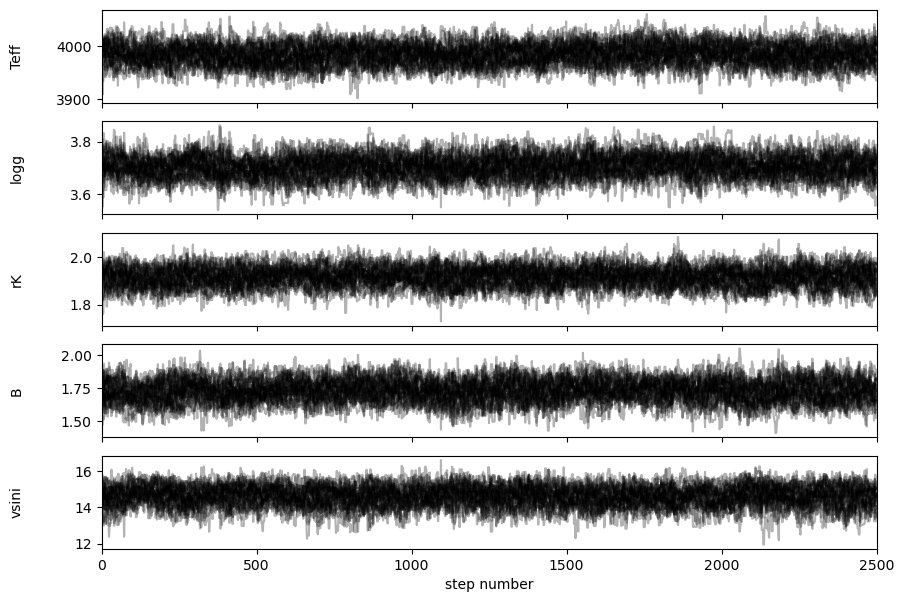

In [32]:
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
discard = 500
samples = sampler.get_chain(discard=discard)
labels = ["Teff", "logg", "rK", "B", "vsini"]

for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

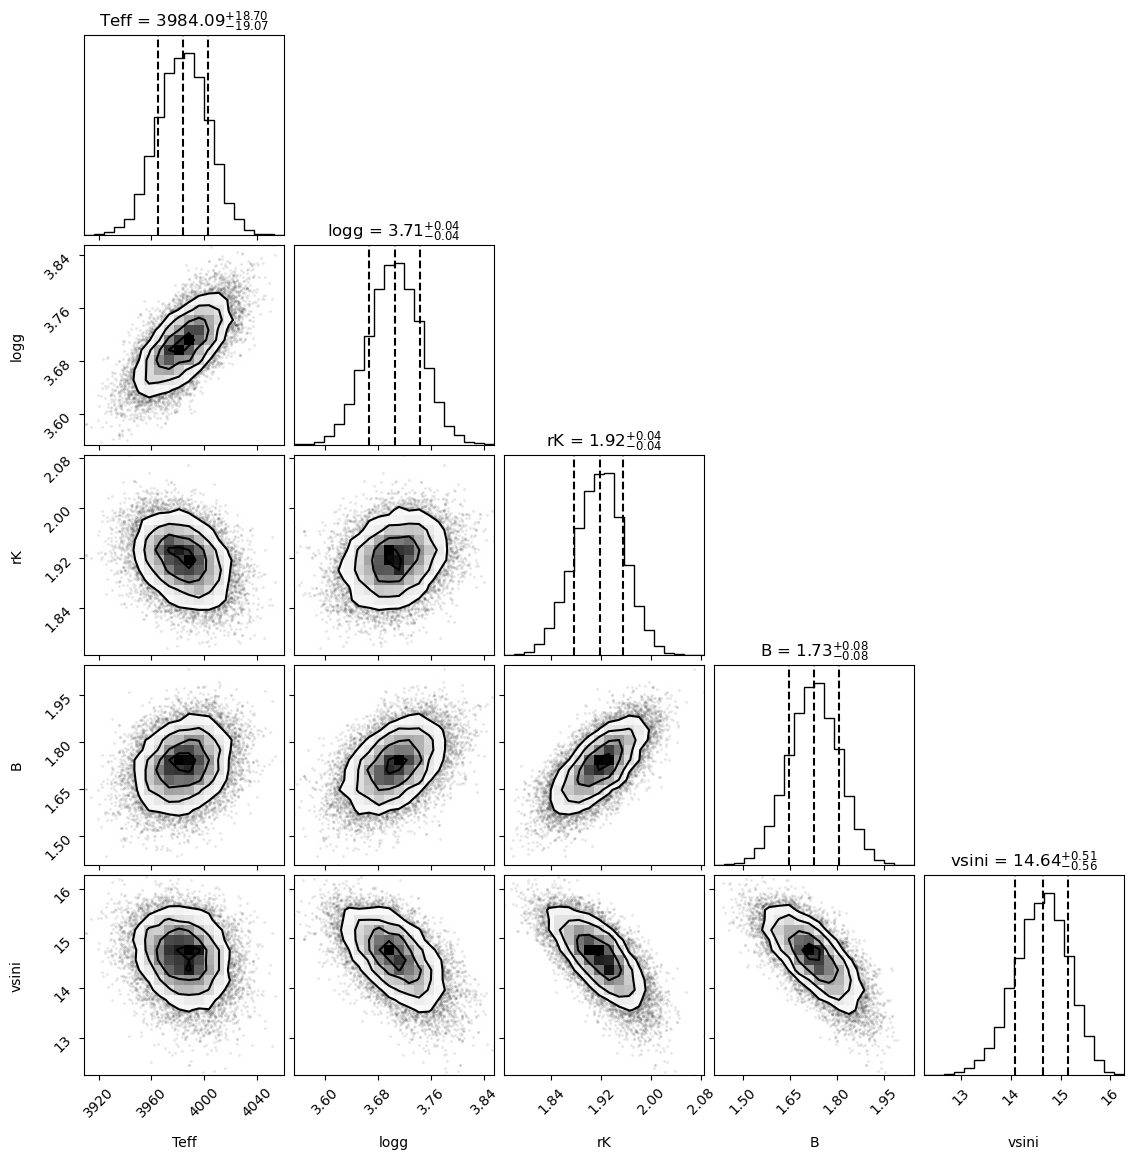

In [35]:
flat_samples = sampler.get_chain(discard=discard, thin=5, flat=True)
# Get truths as percentiles
medians = np.median(flat_samples, axis=0)

fig = corner.corner(
    flat_samples, labels=labels,
    quantiles = [0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12}
)

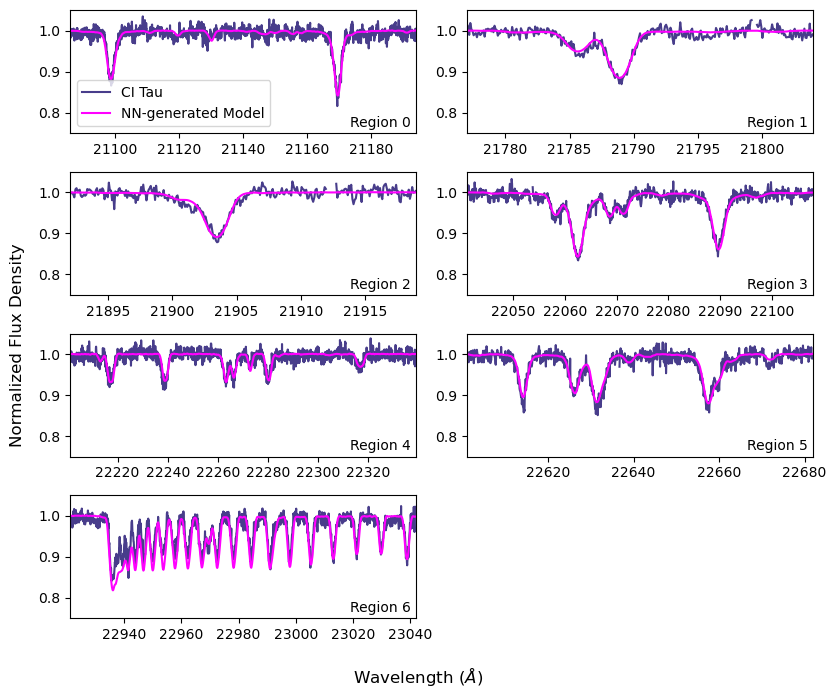

In [34]:
fig, axs = setup_regions_plot()
for r in range(7):
    x, y, yerr = testdata.get_region(r)
    axs[r].plot(x, y, label=testdata.name, color="darkslateblue")
    fitted_model = moognn.make_moogstokes_model(Teff=medians[0], logg=medians[1], rK=medians[2], B=medians[3], vsini=medians[4], region=r)
    axs[r].plot(fitted_model.x, fitted_model.y, label="NN-generated Model", color="fuchsia")
    axs[r].set_ylim(0.75, 1.05)

    if r == 0:
        axs[r].legend()

plt.show()